# Broadside Electromagnetic Array Modeler (BEAM): Dipole Antenna Array Simulation

Complete simulation of dipole antenna arrays in Python, including:
- **Part 1:** Single dipole antenna analysis
- **Part 2:** 10-element antenna array
- **Part 3:** Electronic beam steering

Author: Benito Fernández


In [43]:
## Import Libraries
## Required packages for electromagnetic simulations and 3D visualization.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D


In [44]:
## System Parameters
## Define the fundamental constants and antenna array configuration.

# === Constants and Parameters ===
f = 1e9  # Operating frequency (1 GHz)
c = 299792458  # Speed of light (m/s)
wavelength = c / f  # Wavelength (m)
L = wavelength / 2  # Dipole length (half-wave)
Z_in = 73 + 1j * 42.5  # Theoretical input impedance
Z_0 = 50  # System characteristic impedance (Ohms)

# Array Parameters
N = 10  # Number of elements in the array
d = wavelength / 2  # Element spacing (half wavelength)

print("="*80)
print("DIPOLE ANTENNA ARRAY SIMULATION")
print("="*80)
print(f"Frequency: {f/1e9:.1f} GHz")
print(f"Wavelength: {wavelength*1000:.2f} mm")
print(f"Dipole length: {L*1000:.2f} mm")
print(f"Number of elements: {N}")
print(f"Element spacing: {d*1000:.2f} mm")
print("="*80)

DIPOLE ANTENNA ARRAY SIMULATION
Frequency: 1.0 GHz
Wavelength: 299.79 mm
Dipole length: 149.90 mm
Number of elements: 10
Element spacing: 149.90 mm


# Part 1: Single Dipole Antenna

Analysis of a half-wave dipole antenna including:
- S11 parameter calculation and frequency sweep
- 3D radiation pattern computation
- Element factor normalization
print("\n[1/3] Computing single dipole antenna...")

In [45]:
# === S11 Parameter Calculation ===
gamma = (Z_in - Z_0) / (Z_in + Z_0)
S11_dB = 20 * np.log10(np.abs(gamma))
print(f"  |S11| = {S11_dB:.2f} dB")

# Frequency sweep for S11 analysis
freq_range = np.linspace(0.01e9, 2e9, 500)
S11_sweep = []
for freq in freq_range:
    Z_approx = 73 + 1j * 42.5 * ((freq/f) - (f/freq))
    gamma_sweep = (Z_approx - Z_0) / (Z_approx + Z_0)
    S11_sweep.append(20 * np.log10(np.abs(gamma_sweep)))

# === Radiation Pattern Calculation ===
theta = np.linspace(1e-6, np.pi - 1e-6, 100)
phi = np.linspace(0, 2 * np.pi, 100)
theta_grid, phi_grid = np.meshgrid(theta, phi)

# E-field pattern for half-wave dipole
E_pattern = np.cos((np.pi/2) * np.cos(theta_grid)) / np.sin(theta_grid)
E_pattern[np.isnan(E_pattern)] = 0

# Normalize the pattern
max_E = np.max(np.abs(E_pattern))
if max_E > 0:
    E_pattern_normalized = np.abs(E_pattern) / max_E
else:
    E_pattern_normalized = np.zeros_like(E_pattern)

print("  ✓ Single dipole calculations complete")

  |S11| = -8.60 dB
  ✓ Single dipole calculations complete


### Visualization: Single Dipole - 3D Model, S11, and Radiation Pattern

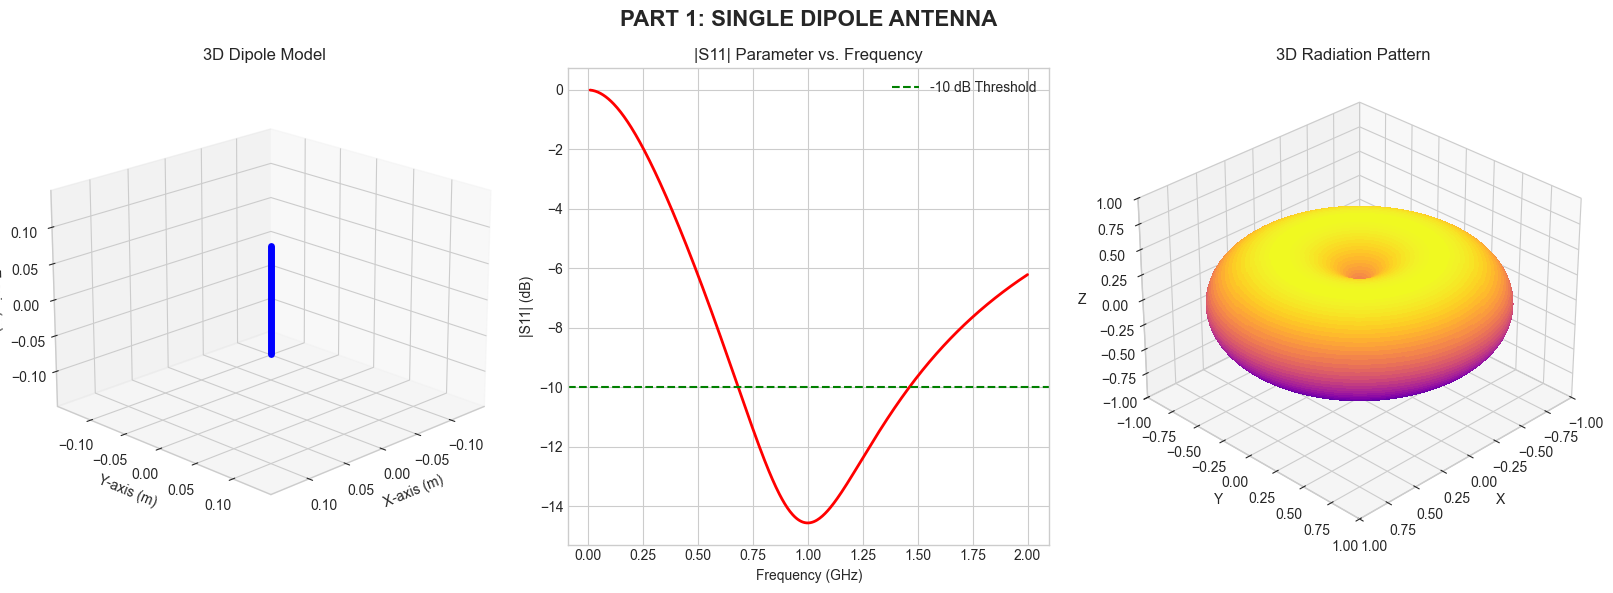

In [46]:
plt.style.use('seaborn-v0_8-whitegrid')

fig1 = plt.figure(figsize=(16, 6))
fig1.suptitle('PART 1: SINGLE DIPOLE ANTENNA', fontsize=16, fontweight='bold')

# 3D Dipole Model
ax1 = fig1.add_subplot(131, projection='3d')
ax1.set_title('3D Dipole Model')
ax1.plot([0, 0], [0, 0], [-L/2, L/2], 'b-', linewidth=5)
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')
ax1.set_zlabel('Z-axis (m)')
ax1.set_xlim([-L, L])
ax1.set_ylim([-L, L])
ax1.set_zlim([-L, L])
ax1.view_init(elev=20, azim=45)

# S11 Parameter vs Frequency
ax2 = fig1.add_subplot(132)
ax2.plot(freq_range / 1e9, S11_sweep, 'r-', linewidth=2)
ax2.set_title('|S11| Parameter vs. Frequency')
ax2.set_xlabel('Frequency (GHz)')
ax2.set_ylabel('|S11| (dB)')
ax2.grid(True)
ax2.axhline(y=-10, color='g', linestyle='--', label='-10 dB Threshold')
ax2.legend()

# 3D Radiation Pattern
ax3 = fig1.add_subplot(133, projection='3d')
ax3.set_title('3D Radiation Pattern')
x = E_pattern_normalized * np.sin(theta_grid) * np.cos(phi_grid)
y = E_pattern_normalized * np.sin(theta_grid) * np.sin(phi_grid)
z = E_pattern_normalized * np.cos(theta_grid)
ax3.plot_surface(x, y, z, rstride=1, cstride=1, cmap=cm.plasma, linewidth=0, antialiased=False)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_xlim([-1, 1])
ax3.set_ylim([-1, 1])
ax3.set_zlim([-1, 1])
ax3.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()

### Visualization: Single Dipole - 2D Polar Patterns

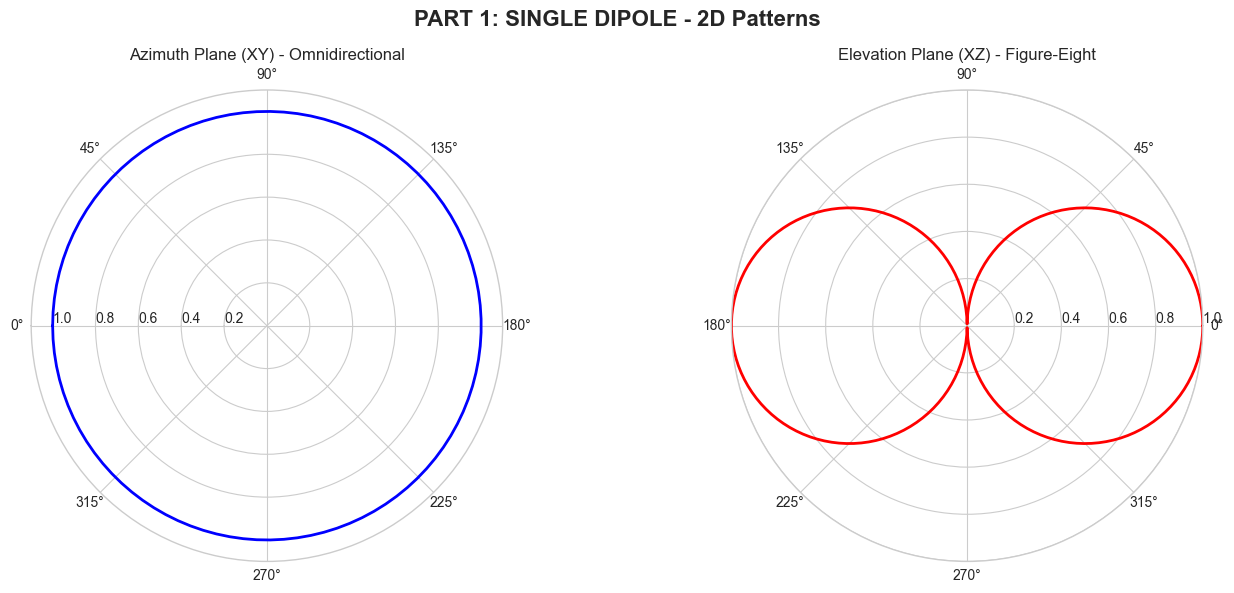

In [47]:
fig2, (ax_az1, ax_el1) = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(14, 6))
fig2.suptitle('PART 1: SINGLE DIPOLE - 2D Patterns', fontsize=16, fontweight='bold')

# Azimuth Plane (H-plane)
phi_plot = np.linspace(0, 2 * np.pi, 100)
azimuth_pattern = np.ones_like(phi_plot)
ax_az1.plot(phi_plot, azimuth_pattern, 'b-', linewidth=2)
ax_az1.set_title('Azimuth Plane (XY) - Omnidirectional', fontsize=12)
ax_az1.set_theta_zero_location('W')
ax_az1.set_theta_direction(-1)
ax_az1.set_rlabel_position(0)
ax_az1.set_rlim([0, 1.1])
ax_az1.grid(True)

# Elevation Plane (E-plane)
theta_plot = np.linspace(0, 2 * np.pi, 200)
elevation_pattern = np.abs(np.cos(theta_plot))
ax_el1.plot(theta_plot, elevation_pattern, 'r-', linewidth=2)
ax_el1.set_title('Elevation Plane (XZ) - Figure-Eight', fontsize=12)
ax_el1.set_theta_zero_location('E')
ax_el1.set_rlabel_position(0)
ax_el1.set_rlim([0, 1])
ax_el1.grid(True)

plt.tight_layout()
plt.show()

---
# Part 2: Antenna Array

Analysis of a linear array with N elements including:
- Element Factor (EF) from single dipole
- Array Factor (AF) calculation
- Combined radiation pattern (EF × AF)

In [48]:
print("[2/3] Computing antenna array...")

# Element Factor (EF)
E_element = np.cos((np.pi/2) * np.cos(theta_grid)) / np.sin(theta_grid)
max_E_element = np.max(np.abs(E_element))
if max_E_element > 0:
    E_element_normalized = np.abs(E_element) / max_E_element
else:
    E_element_normalized = np.zeros_like(E_element)

# Array Factor (AF)
k = 2 * np.pi / wavelength  # Wave number
psi = k * d * np.sin(theta_grid) * np.cos(phi_grid)

denominator = np.sin(psi / 2)
array_factor = np.zeros_like(psi)

# Handle division by zero
non_zero_indices = np.abs(denominator) > 1e-9
array_factor[non_zero_indices] = np.sin(N * psi[non_zero_indices] / 2) / denominator[non_zero_indices]
array_factor[np.abs(denominator) < 1e-9] = N

# Total Combined Pattern (EF × AF)
E_total_pattern = E_element_normalized * np.abs(array_factor)
max_E_total = np.max(E_total_pattern)
if max_E_total > 0:
    E_total_normalized = E_total_pattern / max_E_total
else:
    E_total_normalized = np.zeros_like(E_total_pattern)

print("  ✓ Antenna array calculations complete")

[2/3] Computing antenna array...
  ✓ Antenna array calculations complete


### Visualization: Antenna Array - 3D Model and Radiation Pattern

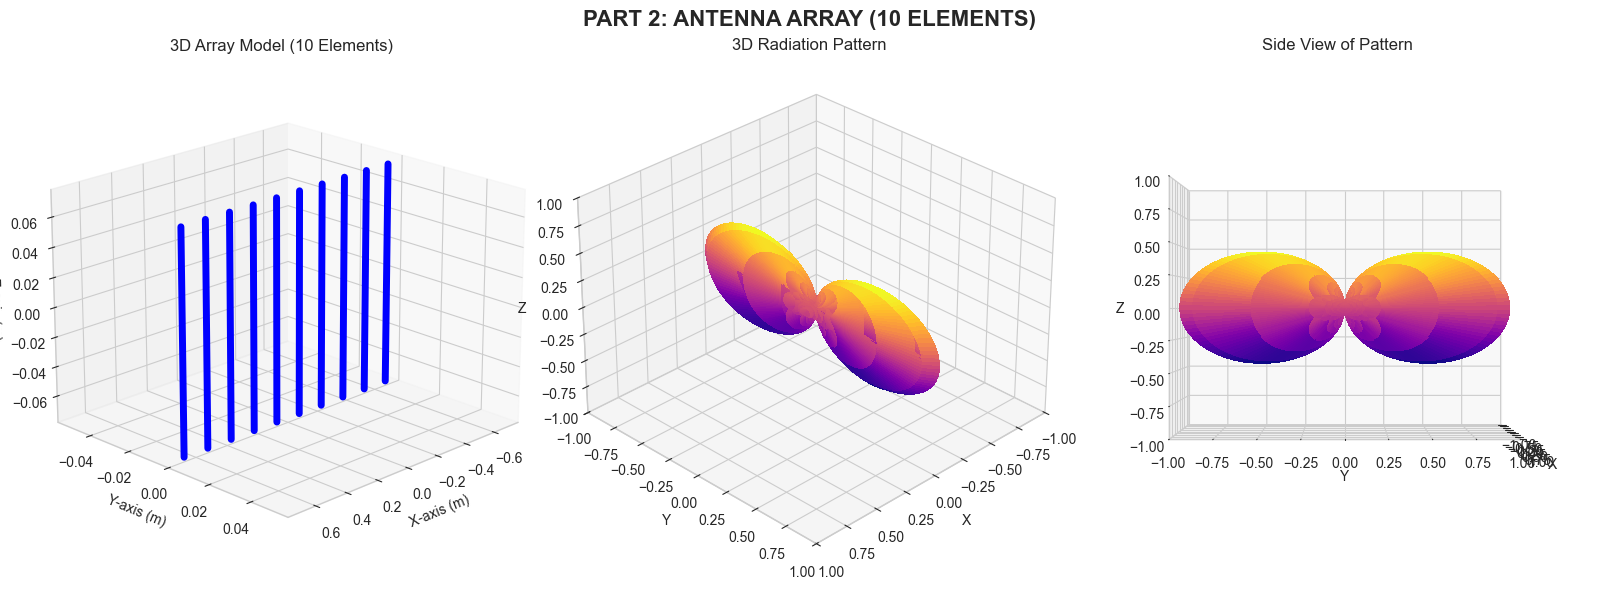

In [49]:
fig3 = plt.figure(figsize=(16, 6))
fig3.suptitle(f'PART 2: ANTENNA ARRAY ({N} ELEMENTS)', fontsize=16, fontweight='bold')

# 3D Array Model
ax4 = fig3.add_subplot(131, projection='3d')
ax4.set_title(f'3D Array Model ({N} Elements)')
for i in range(N):
    x_pos = (i - (N - 1) / 2) * d
    ax4.plot([x_pos, x_pos], [0, 0], [-L/2, L/2], 'b-', linewidth=5)
ax4.set_xlabel('X-axis (m)')
ax4.set_ylabel('Y-axis (m)')
ax4.set_zlabel('Z-axis (m)')
ax4.view_init(elev=20, azim=45)

# 3D Radiation Pattern - Front View
ax5 = fig3.add_subplot(132, projection='3d')
ax5.set_title('3D Radiation Pattern')
x_array = E_total_normalized * np.sin(theta_grid) * np.cos(phi_grid)
y_array = E_total_normalized * np.sin(theta_grid) * np.sin(phi_grid)
z_array = E_total_normalized * np.cos(theta_grid)
ax5.plot_surface(x_array, y_array, z_array, rstride=1, cstride=1, cmap=cm.plasma, linewidth=0, antialiased=False)
ax5.set_xlabel('X')
ax5.set_ylabel('Y')
ax5.set_zlabel('Z')
ax5.set_xlim([-1, 1])
ax5.set_ylim([-1, 1])
ax5.set_zlim([-1, 1])
ax5.view_init(elev=30, azim=45)

# 3D Radiation Pattern - Side View
ax6 = fig3.add_subplot(133, projection='3d')
ax6.set_title('Side View of Pattern')
ax6.plot_surface(x_array, y_array, z_array, rstride=1, cstride=1, cmap=cm.plasma, linewidth=0, antialiased=False)
ax6.set_xlabel('X')
ax6.set_ylabel('Y')
ax6.set_zlabel('Z')
ax6.set_xlim([-1, 1])
ax6.set_ylim([-1, 1])
ax6.set_zlim([-1, 1])
ax6.view_init(elev=0, azim=0)

plt.tight_layout()
plt.show()

### Visualization: Antenna Array - 2D Polar Patterns

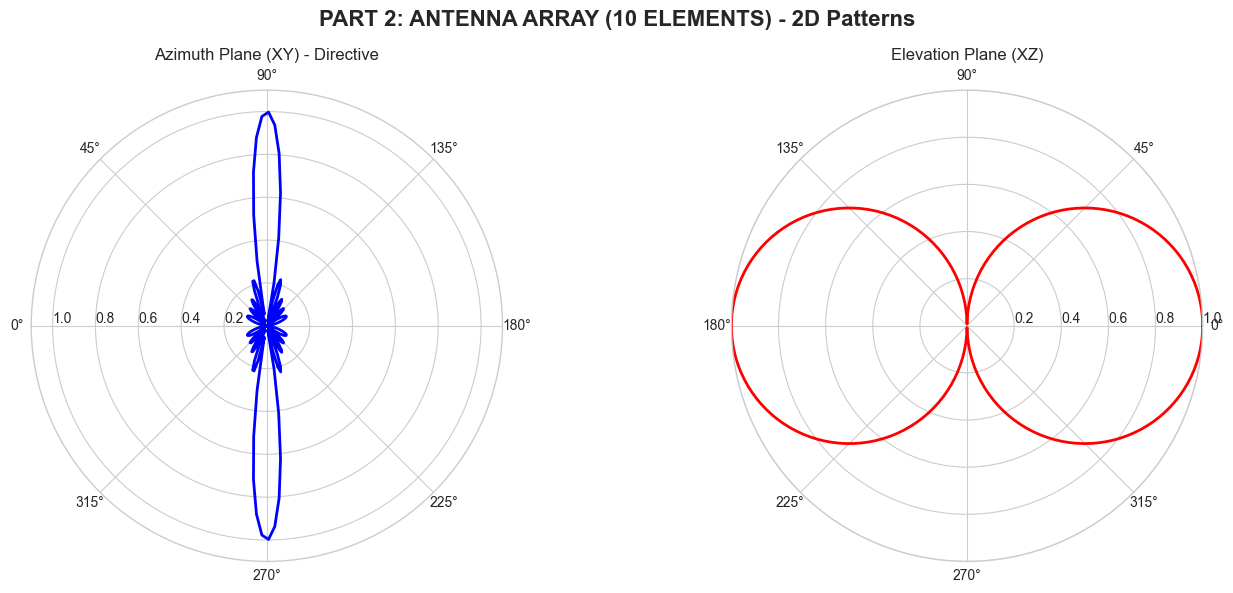

In [50]:
fig4, (ax_az2, ax_el2) = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(14, 6))
fig4.suptitle(f'PART 2: ANTENNA ARRAY ({N} ELEMENTS) - 2D Patterns', fontsize=16, fontweight='bold')

# Azimuth Plane of the array
phi_plot_array = np.linspace(0, 2 * np.pi, 200)
psi_azimuth = k * d * np.sin(np.pi/2) * np.cos(phi_plot_array)
denominator_azimuth = np.sin(psi_azimuth / 2)
array_factor_azimuth = np.zeros_like(psi_azimuth)

non_zero_indices_az = np.abs(denominator_azimuth) > 1e-9
array_factor_azimuth[non_zero_indices_az] = np.sin(N * psi_azimuth[non_zero_indices_az] / 2) / denominator_azimuth[non_zero_indices_az]
array_factor_azimuth[np.abs(denominator_azimuth) < 1e-9] = N

azimuth_pattern_array = np.abs(array_factor_azimuth) / N
ax_az2.plot(phi_plot_array, azimuth_pattern_array, 'b-', linewidth=2)
ax_az2.set_title('Azimuth Plane (XY) - Directive', fontsize=12)
ax_az2.set_theta_zero_location('W')
ax_az2.set_theta_direction(-1)
ax_az2.set_rlabel_position(0)
ax_az2.set_rlim([0, 1.1])
ax_az2.grid(True)

# Elevation Plane of the array
element_factor_elevation = np.abs(np.cos(theta_plot))
ax_el2.plot(theta_plot, element_factor_elevation, 'r-', linewidth=2)
ax_el2.set_title('Elevation Plane (XZ)', fontsize=12)
ax_el2.set_theta_zero_location('E')
ax_el2.set_rlabel_position(0)
ax_el2.set_rlim([0, 1])
ax_el2.grid(True)

plt.tight_layout()
plt.show()

---
# Part 3: Beam Steering

Electronic beam steering by introducing progressive phase shifts between array elements.

The steering equation: **α = -kd cos(θ₀)**

Where:
- α: progressive phase shift
- k: wave number (2π/λ)
- d: element spacing
- θ₀: steering angle

In [51]:
print("[3/3] Computing beam steering...")

psi_degrees_list = [0, 45, 90, 135, 180, 225, 270, 315, 360]

# Store patterns for beam steering
beam_steering_patterns = []

for psi_degree in psi_degrees_list:
    psi_steer = np.radians(psi_degree)
    psi_steered = k * d * np.sin(theta_grid) * np.cos(phi_grid) + psi_steer
    
    denominator_steered = np.sin(psi_steered / 2)
    array_factor_steered = np.zeros_like(psi_steered)
    
    non_zero_indices_steered = np.abs(denominator_steered) > 1e-9
    array_factor_steered[non_zero_indices_steered] = np.sin(N * psi_steered[non_zero_indices_steered] / 2) / denominator_steered[non_zero_indices_steered]
    array_factor_steered[np.abs(denominator_steered) < 1e-9] = N
    
    E_steered = E_element_normalized * np.abs(array_factor_steered)
    max_E_steered = np.max(E_steered)
    if max_E_steered > 0:
        E_steered /= max_E_steered
    else:
        E_steered = np.zeros_like(E_steered)
    
    beam_steering_patterns.append(E_steered)

print("  ✓ Beam steering calculations complete")
print("\n✓ All computations finished. Generating final visualization...\n")

[3/3] Computing beam steering...
  ✓ Beam steering calculations complete

✓ All computations finished. Generating final visualization...



---
# Summary

**Simulation completed successfully!**

### Results:
- **Single Dipole:** Omnidirectional pattern in azimuth plane
- **Array of 10 Elements:** Enhanced directivity and gain
- **Beam Steering:** Electronic control in 9 directions (45° increments)

### Key Observations:
1. The array factor creates a highly directive main lobe
2. Side lobes appear due to constructive/destructive interference
3. Progressive phase shifts enable electronic beam steering without mechanical movement

In [52]:
print("\n" + "="*80)
print("✓ SIMULATION COMPLETED SUCCESSFULLY")
print("="*80)
print("\nSummary:")
print(f"  • Single dipole: Omnidirectional pattern in azimuth")
print(f"  • Array of {N} elements: Enhanced directivity and gain")
print(f"  • Beam Steering: Electronic control in 9 directions")
print("="*80)


✓ SIMULATION COMPLETED SUCCESSFULLY

Summary:
  • Single dipole: Omnidirectional pattern in azimuth
  • Array of 10 elements: Enhanced directivity and gain
  • Beam Steering: Electronic control in 9 directions
